In [1]:
import numpy as np
import pandas as pd
from getSimRes import getSimRes
import matplotlib.pyplot as plt

In [2]:
plt.figure(figsize=(10, 5))
plt.rcParams.update({
    "text.usetex": False,
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 12,            # Tamaño general de la fuente
    "axes.titlesize": 16,       # Tamaño de la fuente para el título de los ejes
    "axes.labelsize": 14,       # Tamaño de la fuente para las etiquetas de los ejes
    "xtick.labelsize": 12,      # Tamaño de la fuente para las etiquetas de los ticks en el eje x
    "ytick.labelsize": 12,      # Tamaño de la fuente para las etiquetas de los ticks en el eje y
    "legend.fontsize": 12,      # Tamaño de la fuente para la leyenda
    "figure.titlesize": 16      # Tamaño de la fuente para el título de la figura
})

<Figure size 1000x500 with 0 Axes>

In [3]:
# Definición de los exponentes de Wöhler para diferentes variables
m_values = {
    'LSSGagMya_[kN-m]': 4, 
    'LSSGagMza_[kN-m]': 4, 
    'TwrBsMxt_[kN-m]': 4, 
    'TwrBsMyt_[kN-m]': 4
}

for i in range(1, 3):
    m_values[f'RootMxb{i}_[kN-m]'] = 10
    m_values[f'RootMyb{i}_[kN-m]'] = 10

# Lista de variables a analizar
variables = ['RootMxb1_[kN-m]','RootMyb1_[kN-m]', 'TwrBsMyt_[kN-m]', 'TwrBsMxt_[kN-m]']
varnames = ['EdgeWise','FlapWise', 'Fore-aft', 'SideSide']
# Parámetros constantes para la función getSimRes
DLC_choice = '3p1'  
U = '14.0'
variation = ''#'_ROSCO_SDTime'
root_name = 'IEA-3.4-130-RWT_'
seeds = [13426, 13427, 13428, 13429, 13430, 13431]          # Seeds for turbsim
DLC_folder = 'DLCs_post_pro'
DLCs = ['1p1','2p1', '3p1', '4p1'] 
TurbSim_DLCs = ['1p1','2p1'] 
Teq = 1
bins = 100  # Puede ser int o list
nbins = bins if isinstance(bins, int) else len(bins) - 1*(len(bins) > 1)
seeds_index =0
# Define el intervalo de tiempo útil
dt = 0.00625  # Intervalo de tiempo
start_index = int(60 / dt)  # Convierte 60 segundos a índices
end_index = int(660/dt)  # O define hasta dónde quieres seleccionar


In [ ]:
# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"]#, "S", "N", "bins", "DELi"]
#columns = ["Simulation Name", "Leq"] + \
#    [f"S_{i}" for i in range(1, nbins + 1)] + \
#    [f"N_{i}" for i in range(1, nbins + 1)] + \
#    [f"bins_{i}" for i in range(1, nbins + 2)] + \
#    [f"DELi_{i}" for i in range(1, nbins + 1)]

# Diccionario para almacenar los resultados
resultados = {var: [] for var in variables}

# Procesamiento de cada variable
for var in variables:
    m = m_values[var]

    # Simulaciones para diferentes velocidades de viento
    for v in np.arange(4.0, 26.0, 1.0):
        simName = f'{root_name}{DLC_choice}_{v}.outb'
        #Leq, S, N, bins, DELi = getSimRes(simName,DLC_folder, var, m, Teq, bins, DLC_choice, start_index, end_index, variation,v,seeds_index=None, seeds=None)
        #print(Leq)# Almacena los resultados en el diccionario
        #resultados[var].append([simName, Leq] + S.tolist() + N.tolist() + bins.tolist() + DELi.tolist())
        Leq= getSimRes(simName,DLC_folder, var, m, Teq, bins, DLC_choice, start_index, end_index, variation,v,seeds_index=None, seeds=None)
        #print(Leq)# Almacena los resultados en el diccionario
        resultados[var].append([simName, Leq])

# Convertir resultados a DataFrames para análisis o gráficos
resultados_df = {var: pd.DataFrame(data, columns=columns) for var, data in resultados.items()}

# Ejemplo de uso de los DataFrames
for var, df in resultados_df.items():
    print(f"Resultados para {var}:")
    print(df.head())
    

In [ ]:
columns = ["Simulation Name", "Leq"]#, "S", "N", "bins", "DELi"]
# Convertir resultados a DataFrames para análisis o gráficos
resultados_df = {var: pd.DataFrame(data, columns=columns) for var, data in resultados.items()}

# Ejemplo de uso de los DataFrames
for var, df in resultados_df.items():
    print(f"Resultados para {var}:")
    print(df.head())

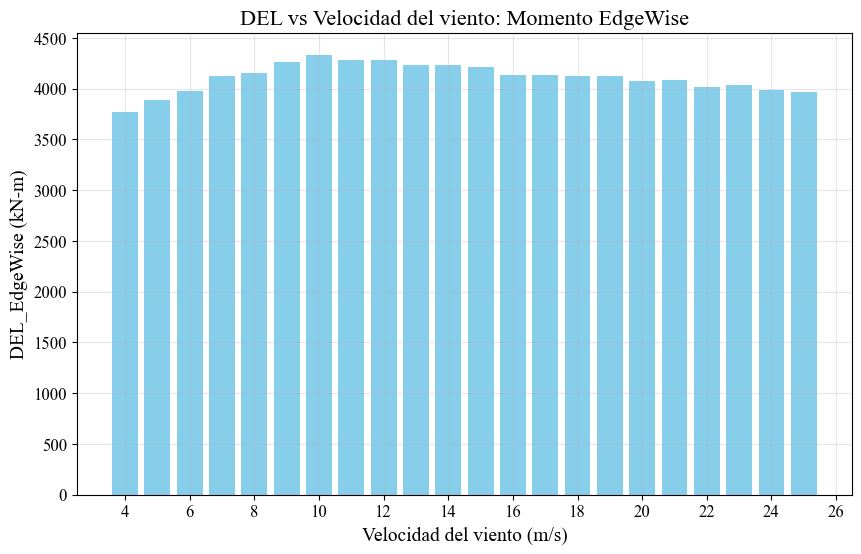

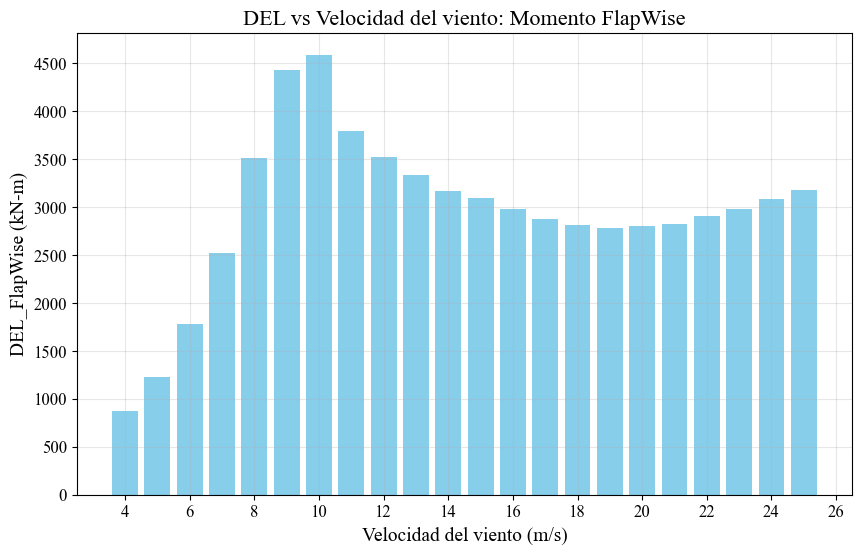

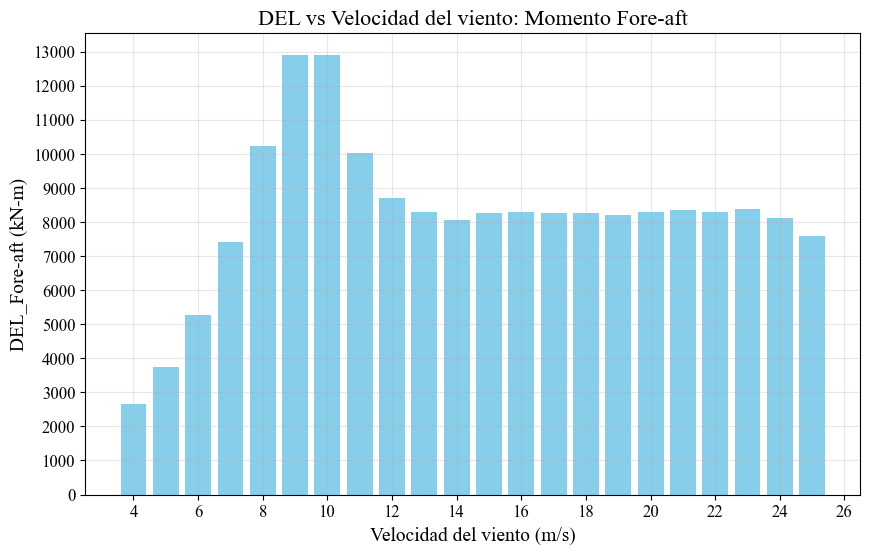

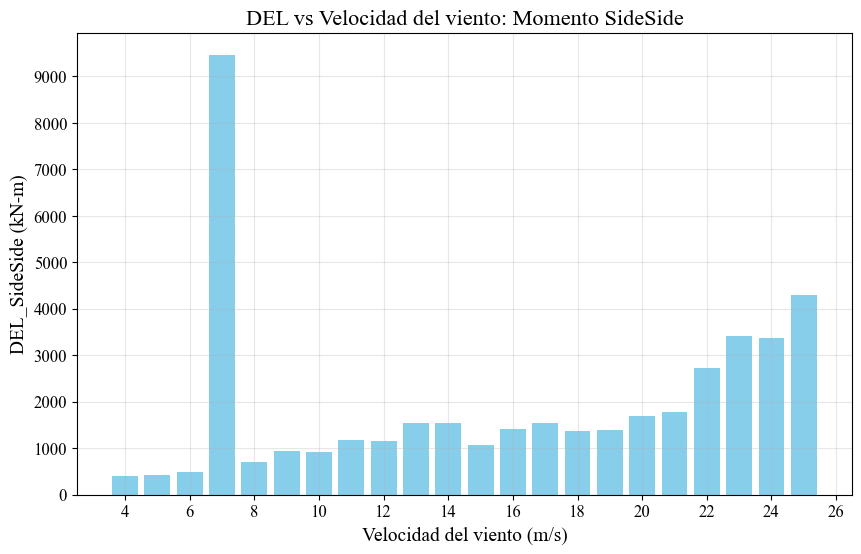

In [11]:
i=0
# Procesa cada DataFrame en resultados_df
for var, df in resultados_df.items():
    #print(var,df)
    # Extraer la velocidad del viento del "Simulation Name"
    df['v'] = df['Simulation Name'].apply(lambda x: float(x.split('_')[-1].replace('.outb', '')))

    # Extraer los valores de Leq
    Leq_values = df['Leq']

    # Crear la gráfica de barras
    plt.figure(figsize=(10, 6))
    plt.bar(df['v'], Leq_values, color='skyblue',alpha=1.0)

    # Configuración de la gráfica
    plt.xlabel('Velocidad del viento (m/s)')
    plt.ylabel(f'DEL_{varnames[i]} (kN-m)')
    plt.title(f'DEL vs Velocidad del viento: Momento {varnames[i]}')
    #plt.grid(axis='y')
    plt.grid(alpha=0.3)
    plt.locator_params(axis='both', nbins=15)
    # Mostrar la gráfica
    plt.show()
    i +=1



In [ ]:
# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"] #+ \
    #[f"S_{i}" for i in range(1, nbins + 1)] + \
    #[f"N_{i}" for i in range(1, nbins + 1)] + \
    #[f"bins_{i}" for i in range(1, nbins + 2)] + \
    #[f"DELi_{i}" for i in range(1, nbins + 1)]

# Procesamiento de cada variable
DLCs = ['3p1','4p1'] #'2p1','1p1','2p1',
# Diccionario para almacenar los valores máximos de Leq para cada caso y variable
max_DEL = {case: {var: None for var in variables} for case in DLCs}

for case in DLCs:
    if case == '4p1':
        variation = '_ROSCO_SDTime'
    else:
        variation = ''
    # Diccionario para almacenar los resultados
    resultados_case = {var: [] for var in variables}
    for var in variables:
        m = m_values[var]

        # Simulaciones para diferentes velocidades de viento
        for v in np.arange(4.0, 26.0, 1.0):
            simName = f'{root_name}{case}_{v}.outb'
           # Leq, S, N, bins, DELi = getSimRes(simName, DLC_folder,var, m, Teq, bins, case,start_index,end_index, variation,v, seeds_index=None, seeds=None)
            Leq = getSimRes(simName, DLC_folder,var, m, Teq, bins, case,start_index,end_index, variation,v, seeds_index=None, seeds=None)

            # Almacena los resultados en el diccionario
            #resultados_case[var].append([simName, Leq] + S.tolist() + N.tolist() + bins.tolist() + DELi.tolist())
            resultados_case[var].append([simName, Leq])

    # Convertir resultados a DataFrames para análisis o gráficos
    resultados_case_df = {var: pd.DataFrame(data, columns=columns) for var, data in resultados_case.items()}
    # Extraer el valor máximo de Leq para cada variable en este caso
    for var, df_max in resultados_case_df.items():
        max_DEL[case][var] = df_max['Leq'].max()
        print(max_DEL[case][var])

# Mostrar los valores máximos de Leq
print(max_DEL)

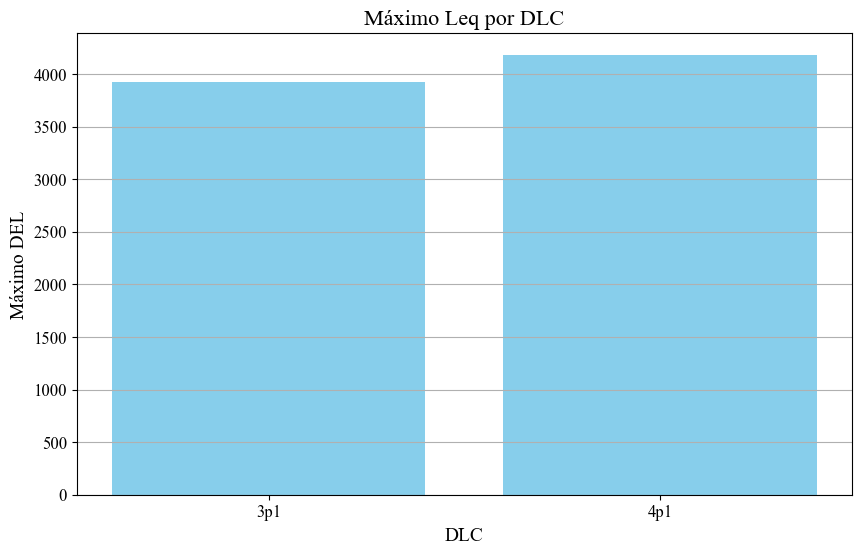

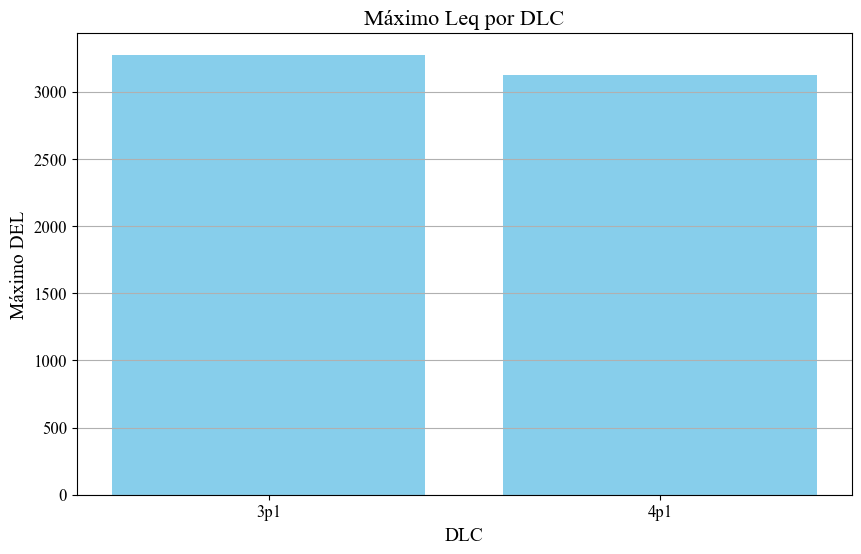

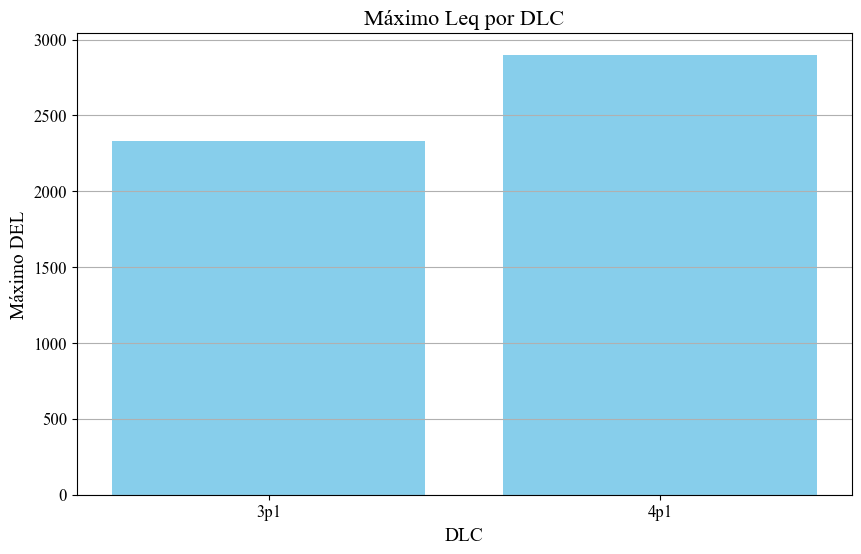

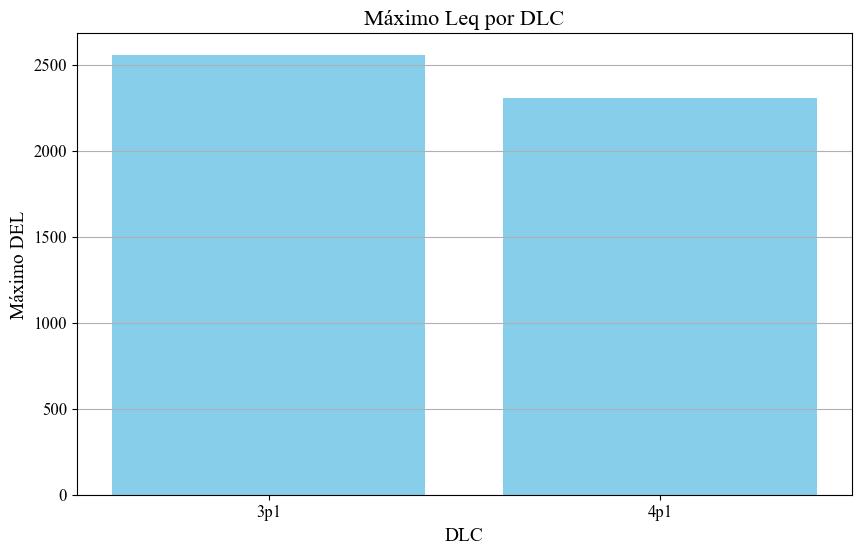

In [19]:
for var in variables:
    # Extraer los nombres de los casos (DLCs) y los valores máximos de DEL
    dlc_names = list(max_DEL.keys())        #Da el nombre del DLC
    max_leq_values = [max_DEL[dlc][var] for dlc in dlc_names]   #Le doy el nombre del DLC y de var y me da el valor de max DEL

    # Crear el gráfico de barras
    plt.figure(figsize=(10, 6))
    plt.bar(dlc_names, max_leq_values, color='skyblue')

    # Configuración del gráfico
    plt.xlabel('DLC')
    plt.ylabel('Máximo DEL')
    plt.title('Máximo Leq por DLC')
    plt.grid(axis='y')

    # Mostrar el gráfico
    plt.show()

In [ ]:
# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"] #+ \
 #   [f"S_{i}" for i in range(1, nbins + 1)] + \
 #   [f"N_{i}" for i in range(1, nbins + 1)] + \
 #   [f"bins_{i}" for i in range(1, nbins + 2)] + \
 #   [f"DELi_{i}" for i in range(1, nbins + 1)]

# Procesamiento de cada variable
#DLCs = ['1p1','2p1']#,'3p1','4p1'] #'2p1',
DLC_folder = 'DLCs_3'
# Diccionario para almacenar los valores máximos de Leq para cada caso y variable
max_DEL = {case: {var: None for var in variables} for case in DLCs}
max_DEL_sd = {case: {var: None for var in variables} for case in DLCs}

for case in DLCs:
    if case == '4p1':
        variation = '_ROSCO_SDTime'
    else:
        variation = ''
    # Diccionario para almacenar los resultados
    resultados_case_sd = {var: [] for var in variables}
    for var in variables:
        m = m_values[var]

        # Simulaciones para diferentes velocidades de viento
        for v in np.arange(4.0, 26.0, 1.0):
            if case in TurbSim_DLCs:
                for sd in seeds:
                    simName = f'{root_name}{case}_{v}.outb'
                    ind = seeds.index(sd)
                   # Leq, S, N, bins, DELi = getSimRes(simName, DLC_folder, var, m, Teq, bins, case,start_index, end_index, variation, v, ind, seeds)
                    Leq = getSimRes(simName, DLC_folder, var, m, Teq, bins, case,start_index, end_index, variation, v, ind, seeds)                    
                    # Almacena los resultados en el diccionario
                    resultados_case_sd[var].append([simName, Leq])# + S.tolist() + N.tolist() + bins.tolist() + DELi.tolist())
                    print(f"Simulation: {simName}, Leq: {Leq}")  #, S: {S}, N: {N}, bins: {bins}, DELi: {DELi}")
                for var, df_max_sd in resultados_case_df_sd.items():
                    max_DEL_sd[case][var] = df_max_sd['Leq'].max()    
    # Convertir resultados a DataFrames para análisis o gráficos
    resultados_case_df_sd = {var: pd.DataFrame(data, columns=columns) for var, data in resultados_case_sd.items()}
    # Extraer el valor máximo de Leq para cada variable en este caso
    for var, df_max_sd in resultados_case_df_sd.items():
        max_DEL[case][var] = df_max_sd['Leq'].max()
        #print(max_DEL[case][var])

# Mostrar los valores máximos de Leq
#print(max_DEL)

In [5]:
#MAXIMO DELs con semilla
# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"] + \
    [f"S_{i}" for i in range(1, nbins + 1)] + \
    [f"N_{i}" for i in range(1, nbins + 1)] + \
    [f"bins_{i}" for i in range(1, nbins + 2)] + \
    [f"DELi_{i}" for i in range(1, nbins + 1)]

DLC_folder = 'DLCs_3'
# Diccionario para almacenar los valores máximos de Leq para cada caso y variable
max_DEL = {case: {var: None for var in variables} for case in DLCs}
max_DEL_sd = {case: {v: {var: None for var in variables} for v in np.arange(4.0, 26.0, 1.0)} for case in DLCs}

for case in DLCs:
    if case == '4p1':
        variation = '_ROSCO_SDTime'
    else:
        variation = ''

    # Diccionario para almacenar los resultados
    resultados_case_sd = {var: [] for var in variables}

    # Simulaciones para diferentes velocidades de viento
    for v in np.arange(4.0, 26.0, 1.0):
        if case in TurbSim_DLCs:
            leq_values_for_v = []
            for sd in seeds:
                simName = f'{root_name}{case}_{v}.outb'
                ind = seeds.index(sd)
                for var in variables:
                    m = m_values[var]
                    Leq, S, N, bins, DELi = getSimRes(simName, DLC_folder, var, m, Teq, bins, case, start_index, end_index, variation, v, ind, seeds)
                    
                    # Almacena los resultados en el diccionario
                    resultados_case_sd[var].append([simName, Leq] + S.tolist() + N.tolist() + bins.tolist() + DELi.tolist())
                    leq_values_for_v.append(Leq)
                    print(f"Simulation: {simName}, Leq: {Leq}")  #, S: {S}, N: {N}, bins: {bins}, DELi: {DELi}")
            
            # Guardar el valor máximo de Leq para la velocidad actual (v) entre todas las semillas y variables
            for var in variables:
                max_DEL_sd[case][v][var] = max(leq_values_for_v)

    # Convertir resultados a DataFrames para análisis o gráficos
    resultados_case_df_sd = {var: pd.DataFrame(data, columns=columns) for var, data in resultados_case_sd.items()}

    # Extraer el valor máximo de Leq para cada variable en este caso
    for var, df_max_sd in resultados_case_df_sd.items():
        max_DEL[case][var] = df_max_sd['Leq'].max()

# Mostrar los valores máximos de Leq
print(max_DEL)
print(max_DEL_sd)


C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd0/IEA-3.4-130-RWT_1p1_4.0.outb
Simulation: IEA-3.4-130-RWT_1p1_4.0.outb, Leq: 4221.241319590397
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd0/IEA-3.4-130-RWT_1p1_4.0.outb
Simulation: IEA-3.4-130-RWT_1p1_4.0.outb, Leq: 0.0
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd0/IEA-3.4-130-RWT_1p1_4.0.outb
Simulation: IEA-3.4-130-RWT_1p1_4.0.outb, Leq: 2174.300458498335
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd0/IEA-3.4-130-RWT_1p1_4.0.outb
Simulation: IEA-3.4-130-RWT_1p1_4.0.outb, Leq: 1413.6075215636633
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd1/IEA-3.4-130-RWT_1p1_4.0.outb
Simulation: IEA-3.4-130-RWT_1p1_4.0.outb, Leq: 4170.148864680423
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd1/IEA-3.4-130-RWT_1p1_4.0.outb
Simulation: IEA-3.4-130-RWT_1p1_4.0.outb, Leq: 0.0
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_3/DLC_1/1p1/4.0/sd1/IEA-3.4-

In [ ]:
for var in variables:
    # Extraer los nombres de los casos (DLCs) y los valores máximos de DEL
    #dlc_names = list(max_DEL.keys())        #Da el nombre del DLC
    #max_leq_values = [max_DEL[dlc][var] for dlc in dlc_names]   #Le doy el nombre del DLC y de var y me da el valor de max DEL
    dlc_names_sd = list(max_DEL_sd.keys())        #Da el nombre del DLC
    max_leq_values_sd = [max_DEL_sd[dlc][var] for dlc in dlc_names]
    
    # Crear el gráfico de barras
    plt.figure(figsize=(10, 6))
    plt.bar(dlc_names_sd, max_leq_values_sd, color='skyblue')

    # Configuración del gráfico
    plt.xlabel('DLC')
    plt.ylabel('Máximo DEL')
    plt.title('Máximo Leq por DLC')
    plt.grid(axis='y')

    # Mostrar el gráfico
    plt.show()